# 🏥 Medical Image Diffusion Training

## GPU Training Setup (RTX 4060 - 8GB VRAM)

### Configuration (Optimized for 8GB):
- **Image Size**: 128×128 (memory-optimized)
- **Model Channels**: 64 (full capacity)  
- **Batch Size**: 4
- **Mixed Precision**: FP16 enabled (~50% memory savings)
- **Timesteps**: 1000 (standard DDPM)

### 💡 Scaling Options:
If you have more VRAM or want higher resolution:
- **12GB+ VRAM**: Use `image_size=256`, `batch_size=4`
- **24GB+ VRAM**: Use `image_size=256`, `batch_size=8`

In [ ]:
import sys
from pathlib import Path
import importlib

# Add src to path - use proper Windows path
PROJECT_ROOT = Path(r"c:\Pranav Aditya\Major Project")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Import our modules (reload to get latest changes)
import dataset
import diffusion_model
import config
import trainer

importlib.reload(dataset)
importlib.reload(diffusion_model)
importlib.reload(config)
importlib.reload(trainer)

from dataset import SimpleChestXrayDataset, MedicalDecathlonDataset, get_msd_dataset
from diffusion_model import MaskConditionedDDPM, BlockConsistencyLoss
from config import TrainingConfig, get_default_config
from trainer import DiffusionTrainer

print("✓ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ All imports successful!
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [14]:
# Setup configuration
config = get_default_config()

# Check for GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
config.device = device

if device == 'cuda':
    # GPU Configuration - Optimized for RTX 4060 (8GB VRAM)
    print(f"🚀 GPU Detected: {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"   VRAM: {vram_gb:.1f} GB")
    
    # Memory-optimized settings for 8GB VRAM
    config.image_size = 128      # Reduced resolution
    config.num_epochs = 50       # Good training duration
    config.batch_size = 2        # Small batch to fit in memory
    config.learning_rate = 1e-4
    config.model_channels = 32   # Smaller model for 8GB VRAM
    config.num_timesteps = 1000  # Standard DDPM timesteps
    config.log_every_n_steps = 20
    config.save_every_n_epochs = 5
    config.val_every_n_epochs = 5
    config.mixed_precision = True  # FP16 saves ~50% memory
    
    # Clear any cached memory
    torch.cuda.empty_cache()
    import gc
    gc.collect()
    
else:
    # CPU Configuration
    print("⚠️ No GPU detected - using CPU (slow)")
    config.image_size = 64
    config.num_epochs = 5
    config.batch_size = 2
    config.model_channels = 32
    config.num_timesteps = 100

print("\nTraining Configuration:")
for key, value in config.to_dict().items():
    print(f"  {key}: {value}")

# Create directories
config.checkpoint_dir.mkdir(parents=True, exist_ok=True)
config.log_dir.mkdir(parents=True, exist_ok=True)

print(f"\n💡 Memory-optimized: batch=2, channels=32, attention only at lowest res")

🚀 GPU Detected: NVIDIA GeForce RTX 4060 Laptop GPU
   VRAM: 8.0 GB

Training Configuration:
  image_size: 128
  in_channels: 2
  model_channels: 32
  num_res_blocks: 2
  num_timesteps: 1000
  num_epochs: 50
  batch_size: 2
  learning_rate: 0.0001
  weight_decay: 1e-05
  warmup_steps: 500
  data_root: data\processed
  image_dir: images
  mask_dir: masks
  num_workers: 4
  diffusion_loss_weight: 1.0
  block_consistency_weight: 0.1
  checkpoint_dir: models\checkpoints
  save_every_n_epochs: 5
  val_every_n_epochs: 5
  log_every_n_steps: 20
  log_dir: logs
  use_wandb: False
  device: cuda
  mixed_precision: True
  num_sampling_steps: 50
  guidance_scale: 1.0

💡 Memory-optimized: batch=2, channels=32, attention only at lowest res


In [15]:
# Create datasets (using synthetic data for now)
print("Creating datasets...")

# Larger dataset for GPU training
num_train = 500 if device == 'cuda' else 100
num_val = 100 if device == 'cuda' else 20

train_dataset = SimpleChestXrayDataset(
    num_samples=num_train,
    image_size=config.image_size,
    normalization_type='zero_one'
)

val_dataset = SimpleChestXrayDataset(
    num_samples=num_val,
    image_size=config.image_size,
    normalization_type='zero_one'
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=4 if device == 'cuda' else 0,  # Use workers on GPU
    pin_memory=True if device == 'cuda' else False  # Faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4 if device == 'cuda' else 0,
    pin_memory=True if device == 'cuda' else False
)

print(f"✓ Train dataset: {len(train_dataset)} samples")
print(f"✓ Val dataset: {len(val_dataset)} samples")
print(f"✓ Batch size: {config.batch_size}")
print(f"✓ Image size: {config.image_size}x{config.image_size}")

# Test one batch
sample_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Image: {sample_batch['image'].shape}")
print(f"  Mask: {sample_batch['mask'].shape}")
print(f"  Image range: [{sample_batch['image'].min():.3f}, {sample_batch['image'].max():.3f}]")

Creating datasets...
[Dataset] Using synthetic data: 500 samples
[Dataset] Using synthetic data: 100 samples
✓ Train dataset: 500 samples
✓ Val dataset: 100 samples
✓ Batch size: 2
✓ Image size: 128x128

Batch shapes:
  Image: torch.Size([2, 1, 128, 128])
  Mask: torch.Size([2, 1, 128, 128])
  Image range: [0.000, 1.000]


In [16]:
# Initialize model
print("Initializing Mask-Conditioned DDPM...")

model = MaskConditionedDDPM(
    image_size=config.image_size,  # Use config value (64 for CPU)
    in_channels=2,  # Image + Mask
    model_channels=config.model_channels,  # 32 for CPU
    num_res_blocks=2,
    num_timesteps=config.num_timesteps,  # 100 for CPU testing
    device=device
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model initialized")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Move to device
model.to(device)
print(f"✓ Model moved to {device}")

Initializing Mask-Conditioned DDPM...
✓ Model initialized
  Total parameters: 3,939,681
  Trainable parameters: 3,939,681
✓ Model moved to cuda


In [17]:
# Initialize trainer
trainer = DiffusionTrainer(
    model=model,
    config=config,
    device=device
)

print("✓ Trainer initialized")

✓ Mixed precision (FP16) training enabled
✓ Trainer initialized on cuda
✓ Trainer initialized


In [18]:
# Train the model
print("Starting training...\n")
trainer.fit(train_loader, val_loader)

print("\nTraining complete!")
print(f"Best validation loss: {trainer.best_val_loss:.6f}")

Starting training...

Starting training for 50 epochs...
Config: {'image_size': 128, 'in_channels': 2, 'model_channels': 32, 'num_res_blocks': 2, 'num_timesteps': 1000, 'num_epochs': 50, 'batch_size': 2, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'warmup_steps': 500, 'data_root': 'data\\processed', 'image_dir': 'images', 'mask_dir': 'masks', 'num_workers': 4, 'diffusion_loss_weight': 1.0, 'block_consistency_weight': 0.1, 'checkpoint_dir': 'models\\checkpoints', 'save_every_n_epochs': 5, 'val_every_n_epochs': 5, 'log_every_n_steps': 20, 'log_dir': 'logs', 'use_wandb': False, 'device': 'cuda', 'mixed_precision': True, 'num_sampling_steps': 50, 'guidance_scale': 1.0}



Epoch 0: 100%|██████████| 250/250 [01:04<00:00,  3.87it/s, loss=0.498, diff=0.42, consist=0.786, lr=4.82e-5] 



Epoch 0 Train Metrics:
  total: 0.882037
  diffusion: 0.792879
  consistency: 0.891579


Validation: 100%|██████████| 50/50 [00:06<00:00,  7.51it/s, loss=0.404]


Epoch 0 Val Metrics:
  loss: 0.410023
✓ Checkpoint saved: models\checkpoints\ckpt_epoch_0000.pt
✓ Best model saved: models\checkpoints\best_model.pt
✓ Checkpoint saved: models\checkpoints\ckpt_epoch_0000.pt



...


Epoch 15 Train Metrics:
  total: 0.151258
  diffusion: 0.058682
  consistency: 0.925760


Validation: 100%|██████████| 50/50 [00:06<00:00,  7.29it/s, loss=0.0172]  


Epoch 15 Val Metrics:
  loss: 0.032135
✓ Checkpoint saved: models\checkpoints\ckpt_epoch_0015.pt
✓ Best model saved: models\checkpoints\best_model.pt
✓ Checkpoint saved: models\checkpoints\ckpt_epoch_0015.pt



Epoch 16:  43%|████▎     | 108/250 [00:29<00:39,  3.62it/s, loss=0.224, diff=0.116, consist=1.08, lr=1.81e-5]   


KeyboardInterrupt: 

In [ ]:
# Inspect training metrics
print("Training History:")
print(f"Final train loss: {trainer.train_history['loss'][-1]:.6f}")
print(f"Final val loss: {trainer.val_history['loss'][-1]:.6f}")

# Save final checkpoint
trainer.save_checkpoint(name="final_model.pt")

Training History:
Final train loss: 0.688693
Final val loss: 0.985505
✓ Checkpoint saved: models\checkpoints\final_model.pt


Testing image generation from trained model...

✓ Loaded trained model from checkpoint (epoch 0)
Test mask shape: torch.Size([1, 1, 64, 64])
Lesion region: [24:40, 24:40]
Generated image shape: torch.Size([1, 1, 64, 64])
Generated image range: [0.000, 1.000]
✓ Image generation test passed!


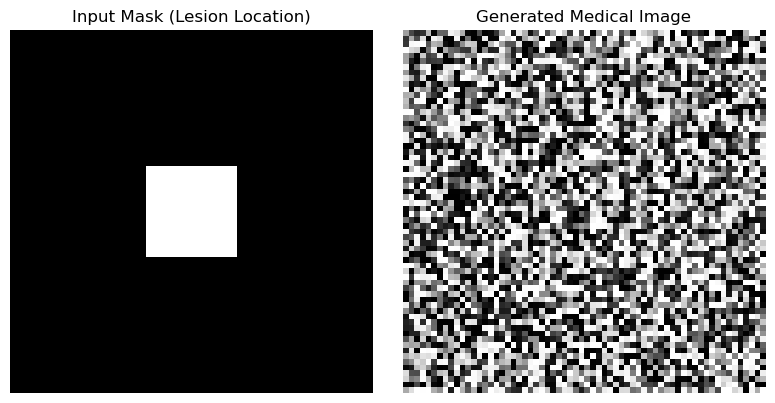

In [ ]:
# Test sampling from trained model
print("Testing image generation from trained model...\n")

# Reload model with trained weights
model = MaskConditionedDDPM(
    image_size=config.image_size,
    in_channels=2,
    model_channels=config.model_channels,
    num_res_blocks=2,
    num_timesteps=config.num_timesteps,
    device=device
)

# Load trained weights
checkpoint = torch.load('models/checkpoints/best_model.pt', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model.to(device)
model.eval()
print(f"✓ Loaded trained model from checkpoint (epoch {checkpoint['epoch']})")

# Create test masks with different lesion positions
img_size = config.image_size
num_samples = 4

fig, axes = plt.subplots(2, num_samples, figsize=(4*num_samples, 8))

for i in range(num_samples):
    # Create mask with random lesion position
    test_mask = torch.zeros(1, 1, img_size, img_size, device=device)
    
    # Random lesion position
    center_y = np.random.randint(img_size//4, 3*img_size//4)
    center_x = np.random.randint(img_size//4, 3*img_size//4)
    lesion_size = max(5, img_size // 8)
    start_y, end_y = center_y - lesion_size, center_y + lesion_size
    start_x, end_x = center_x - lesion_size, center_x + lesion_size
    test_mask[0, 0, start_y:end_y, start_x:end_x] = 1.0
    
    # Generate image
    with torch.no_grad():
        # Use fewer steps for faster generation (DDIM-like speedup)
        num_sample_steps = min(100, config.num_timesteps)
        generated = model.sample(mask=test_mask, batch_size=1, num_steps=num_sample_steps)
    
    # Plot
    axes[0, i].imshow(test_mask[0, 0].cpu(), cmap='gray')
    axes[0, i].set_title(f'Mask {i+1}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(generated[0, 0].cpu().numpy(), cmap='gray')
    axes[1, i].set_title(f'Generated {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Mask-Guided Image Generation', fontsize=14)
plt.tight_layout()
plt.savefig('results/generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Generated {num_samples} samples")
print(f"✓ Saved to results/generated_samples.png")

## Next Steps:

1. **Real Data Loading**: Replace SimpleChestXrayDataset with real CXR + mask data
2. **Hyperparameter Tuning**: Adjust learning rate, batch size, loss weights
3. **Block Consistency Loss Analysis**: Measure lesion location accuracy
4. **Sampling Quality**: Implement DDIM for faster sampling
5. **Visualization**: Create analysis plots for generated vs real images
6. **Ablation Studies**: Test with/without Block Consistency Loss

## Research Notes:

- The Block Consistency Loss is defined in diffusion_model.py
- Adjust `block_consistency_weight` to control lesion localization strength
- Start with weight=0.1, increase if lesions appear outside mask
- Use intermediate diffusion steps (50-100) for quality vs speed tradeoff